In [1]:
import socket
import time
from ogn.parser import parse    # for parsing the raw messages from the OGN TCP stream
from datetime import datetime   
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs      # map plotting library for geospatial data
import cartopy.feature as cfeature

In [ ]:
# Make a TCP connection to the APRS server
# Stream data for a specified time, then close the connection and print the collected lines
# Currently has an issue where the connection goes idle and is closed after 30 mins. Need to modify to send heartbeats to keep connection alive. 

host = 'aprs.glidernet.org'
port = 14580

lines = []
start_time = time.time()
stream_time_hr = 2  # hours to stream data for

with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
    s.connect((host, port))

    stream = s.makefile('r', encoding='utf-8', errors='replace')

    # login_str = "user TobyMet -1 filter b/49.5/-8.5/61/2 p/FLR\r\n"
    login_str = "user TobyMet -1 filter r/53.6/-4.2/800 p/FLR\r\n"
    s.sendall(login_str.encode('utf-8'))

    end_time = start_time + 3600*stream_time_hr  # Run for specified time

    for line in stream:
        lines.append(line.strip())
        if time.time() > end_time:
            s.shutdown(socket.SHUT_RDWR)
            s.close()
            break  # Exit loop

# Socket is now closed, examine lines freely
print(f"Collected {len(lines)} lines")

Collected 1074354 lines


In [2]:
import socket
import threading
import time

host = 'aprs.glidernet.org'
port = 14580

lines = []
start_time = time.time()
stream_time_hr = 1/60  # hours to stream data for
keepalive_interval_sec = 60  # send a heartbeat every 60s of idle time

stop_event = threading.Event()

def send_heartbeats(sock, interval):
    """Periodically send an APRS-IS comment line to keep the connection alive."""
    while not stop_event.wait(interval):
        try:
            sock.sendall(b"#keepalive\r\n")
        except OSError:
            break  # socket already closed

with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
    s.connect((host, port))

    stream = s.makefile('r', encoding='utf-8', errors='replace')

    login_str = "user TobyMet -1 filter r/53.6/-4.2/800 p/FLR\r\n"
    s.sendall(login_str.encode('utf-8'))

    # Start background thread to send periodic keepalives
    heartbeat_thread = threading.Thread(
        target=send_heartbeats, args=(s, keepalive_interval_sec), daemon=True
    )
    heartbeat_thread.start()

    end_time = start_time + 3600 * stream_time_hr  # Run for specified time

    try:
        for line in stream:
            lines.append(line.strip())
            if time.time() > end_time:
                break  # Exit loop
    finally:
        stop_event.set()  # tell heartbeat thread to stop
        s.shutdown(socket.SHUT_RDWR)
        s.close()

# Socket is now closed, examine lines freely
print(f"Collected {len(lines)} lines")

Collected 35826 lines


In [3]:
# Display first few lines.

for line in lines[0:10]:
    print(line)

# aprsc 2.1.20-gf.5-g0178a1b
# logresp TobyMet unverified, server GLIDERN2
PAW400CCA>APRS,qAS,PWEGCM:/113915h5355.95N\00126.25W^359/109/A=003589 !W17! id23400CCA +000fpm +0.0rot 20.0dB 0e -6.0kHz gps1x1
FLRD03185>OGFLR,qAS,Wemding:/113914h4844.47N/01016.03E'321/071/A=004751 !W43! id06D03185 -276fpm +0.1rot 63.8dB +0.4kHz gps1x1 -3.4dBm
ICA44CE61>OGADSB,qAS,AVX993:/113915h5059.15N/00408.04E^075/295/A=011292 !W76! id2544CE61 -1664fpm FL108.11 A3:BEL4UG
ICA398578>OGADSB,qAS,AVX1552:/113915h4853.14N/00248.90E^277/338/A=014577 !W33! id01398578 -64fpm FL140.00
ICA44CD73>OGADSB,qAS,AVX1030:/113915h5110.44N\00412.22E^025/087/A=003106 !W95! id2144CD73 +0fpm FL028.00 A1:OOSKS Sq5104
ICA44CE61>OGADSB,qAS,AVX1030:/113915h5059.15N/00408.04E^075/295/A=011292 !W75! id2544CE61 -1664fpm FL108.11 A3:BEL4UG
FLRDDD4D1>OGFLR,qAS,LFFK:/113911h4626.57N/00045.18W'164/044/A=002149 !W22! id06DDD4D1 +475fpm +4.7rot 11.0dB -12.9kHz gps2x3
ICA4864FA>OGADSB,qAS,AVX993:/113915h5141.91N\00424.05E^271/094/A=001333 !W2

In [ ]:
# Save lines to a text file for later analysis

with open('aprs_data_20260322_T1534-1604.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))

In [ ]:
# Read lines back in from file and parse into DataFrame

root = "C:\\Users\\tobya\\OneDrive - University of Exeter\\Y4\\PHY3150 - Winds from Gliders\\Data\\OGN APRS\\"

# create empty object to hold dicts
records = []

with open('aprs_data_20260322_T1534-1604.txt', 'r') as f:
    for line in f:
        line = line.strip()     # remove leading and trailing whitespace, including \r\n
        if not line or line.startswith('#'):  # skip empty lines and comments
            continue
        try:
            parsed = parse(line)    # Calls the ogn.parser.parse function for each line.
            if parsed:      # parse function returns None for unparseable lines, so check before appending
                records.append(parsed)
        except Exception:
            continue  # skip unparseable lines

df = pd.DataFrame(records)

In [ ]:
# Display summary info about the DataFrame, including column names, data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1073187 entries, 0 to 1073186
Data columns (total 62 columns):
 #   Column                       Non-Null Count    Dtype              
---  ------                       --------------    -----              
 0   raw_message                  1073187 non-null  object             
 1   reference_timestamp          1073187 non-null  datetime64[ns, UTC]
 2   aprs_type                    1073187 non-null  object             
 3   beacon_type                  1073187 non-null  object             
 4   name                         1073187 non-null  object             
 5   dstcall                      1073187 non-null  object             
 6   receiver_name                1073187 non-null  object             
 7   latitude                     1067209 non-null  float64            
 8   longitude                    1067209 non-null  float64            
 9   symboltable                  1067209 non-null  object             
 10  symbolcode        

In [ ]:
# As specified in the OGN documentation, aircraft_type = 1 corresponds to gliders, so filter the DataFrame to only include those records for now.
gliders_df = df[df['aircraft_type'] == 1]

print(f"Total records: {len(df)}, Glider records: {len(gliders_df)}")

Total records: 1073187, Glider records: 592891


In [ ]:
# find measurements outside the expected bounding box
# For some reason some messages outside of the bounding box are still being received, so check how many and which they are.
mask_outside = (
    (gliders_df['latitude'] < 49.5) | (gliders_df['latitude'] > 61) |
    (gliders_df['longitude'] < -8.5) | (gliders_df['longitude'] > 2)
)
print(f"Points outside bounding box: {mask_outside.sum()}")
print(gliders_df[mask_outside][['latitude', 'longitude', 'timestamp', 'name']].head(20))

Points outside bounding box: 530161
     latitude  longitude                 timestamp       name
1   51.961983   7.744617 2026-03-22 15:34:56+00:00  FLRDDA4EE
2   47.869500  11.308400 2026-03-22 15:34:51+00:00  FLRD0043E
3   47.955267  10.791400 2026-03-22 15:34:51+00:00  FLRDD9877
4   51.023617   7.030133 2026-03-22 15:34:56+00:00  FLRD02897
5   51.788950   5.871983 2026-03-22 15:34:56+00:00  ICA484BE1
8   51.451167   4.304267 2026-03-22 15:34:58+00:00  ICA485A0B
10  52.168683   5.167267 2026-03-22 15:34:56+00:00  ICA3ED92B
11  52.193850   5.129050 2026-03-22 15:34:56+00:00  ICA4849B5
12  52.193017   5.145517 2026-03-22 15:34:56+00:00  ICA4849B8
13  52.191133   5.133700 2026-03-22 15:34:56+00:00  ICA4851BB
15  50.796767   6.329133 2026-03-22 15:34:57+00:00  FLRD00BEB
17  50.393067  10.091550 2026-03-22 15:34:57+00:00  FLRD00CBE
18  50.351483  10.464300 2026-03-22 15:34:57+00:00  FLRDDEADE
19  50.543350  10.348300 2026-03-22 15:34:57+00:00  FLRDDEF33
22  52.114350   5.285767 2026-03-2

In [ ]:
t_min = datetime(2026, 3, 22, 15, 33).timestamp()
t_max = datetime(2026, 3, 22, 16, 5).timestamp()
mask_time = (gliders_df['timestamp'].astype('int64') / 10**9 >= t_min) & (gliders_df['timestamp'].astype('int64') / 10**9 <= t_max) # timestamp stored in [ns], hence 1e9 factor.
print(f"Points outside time range: {(~mask_time).sum()}")

Points outside time range: 440


In [ ]:
# Filter for messages within a bounding box around the UK and within the specified time range, and print how many points remain.
mask_inside = (
    (gliders_df['latitude'] >= 49.5) & (gliders_df['latitude'] <= 61) &
    (gliders_df['longitude'] >= -8.5) & (gliders_df['longitude'] <= 2) &
    (gliders_df['timestamp'].astype('int64') / 10**9 >= t_min) & (gliders_df['timestamp'].astype('int64') / 10**9 <= t_max)
)

gliders_uk_df = gliders_df[mask_inside]
print(f"Points inside bounding box: {len(gliders_uk_df)}")

Points inside bounding box: 62693


In [13]:
gliders_uk_df['timestamp_unix'] = gliders_uk_df['timestamp'].astype('int64') / 10**9

C:\Users\tobya\AppData\Local\Temp\ipykernel_25608\4206310119.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gliders_uk_df['timestamp_unix'] = gliders_uk_df['timestamp'].astype('int64') / 10**9


In [14]:
gliders_uk_df.timestamp_unix[0:10]

16    1.774194e+09
27    1.774194e+09
29    1.774194e+09
30    1.774194e+09
32    1.774194e+09
55    1.774194e+09
59    1.774194e+09
70    1.774194e+09
71    1.774194e+09
72    1.774194e+09
Name: timestamp_unix, dtype: float64

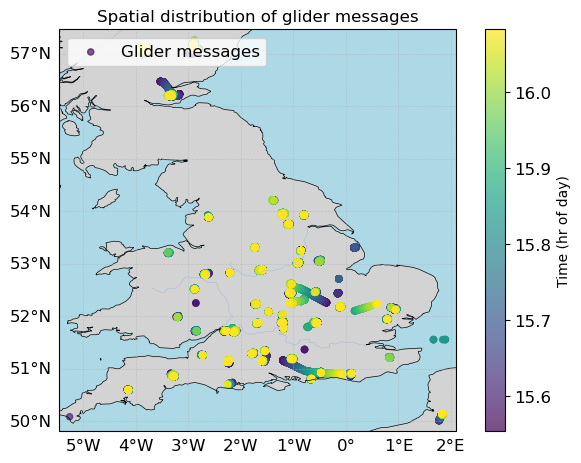

In [ ]:
def plot_messages(df, lat_col='latitude', lon_col='longitude'):

    """
    Plot the spatial distribution of glider messages on a map, coloured by time of day.
     - df: DataFrame containing the glider messages, with columns for latitude, longitude, and timestamp.
     - lat_col, lon_col: names of the columns in df that contain latitude and longitude values, respectively.
     - The function creates a map using Cartopy, plots the glider message locations as a scatter plot coloured by time of day, and displays the map with appropriate features and labels.
     - The timestamp is converted to hours of the day (0-24) for colouring the points, and a colorbar is added to indicate the time scale.
    """

    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 12,
        'axes.labelsize': 10,
        'xtick.labelsize': 10,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
    })

    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
    
    ax.add_feature(cfeature.LAND, facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')
    ax.add_feature(cfeature.RIVERS, linewidth=0.3)
    
    margin = 0.2

    all_lons = list(df[lon_col])
    all_lats = list(df[lat_col])

    ax.set_extent([min(all_lons) - margin, max(all_lons) + margin,
                min(all_lats) - margin, max(all_lats) + margin])
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False

    t_hours = df['timestamp'].astype('int64') // 10**9 % (3600 * 24) / 3600
    vmin, vmax = t_hours.min(), t_hours.max()

    scatter = ax.scatter(df[lon_col], df[lat_col],
                         c=t_hours, cmap='viridis', s=20, alpha=0.7,
                         vmin=vmin, vmax=vmax,
                         transform=ccrs.PlateCarree(),
                         label='Glider messages')

    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('Time (hr of day)')
    ax.set_title('Spatial distribution of glider messages')
    ax.legend(loc='upper left')
    fig.tight_layout()
    plt.show()

plot_messages(gliders_uk_df, lat_col='latitude', lon_col='longitude')

In [ ]:
# Save the filtered DataFrame to a Parquet file for later analysis. Parquet is more efficient than CSV, and can be read directly in with pandas for analysis.

gliders_uk_df.to_parquet('aprs_data_20260322_T1534-1604_UKfilter.parquet')

In [4]:
gliders_uk_df = pd.read_parquet('aprs_data_20260322_T1534-1604_UKfilter.parquet')

In [ ]:
# Now with the messages filtered, we can group them into individual flight tracks.
# Group the glider messages by aircraft (using the icao24 identifier) and store in a dictionary

unq_f = {}      # unique flights
grouped = gliders_uk_df.groupby('name')      # Group rows in the DataFrame by the 'name' column, which identifies individual aircraft

for icao, group in grouped:
    unq_f[icao] = group   

In [ ]:
print(f"num of unique aircraft: {len(unq_f.keys())}")
unq_f.keys()
nmes = np.empty(len(unq_f.keys()))
keys = np.empty(len(unq_f.keys()), dtype='U32')  # Use string dtype for keys

i = 0
for key in unq_f.keys():
    nmes[i], keys[i] = len(unq_f[key]), key     # nmes: number of messages for this aircraft; key: name of the aircraft
    i += 1

# Sort keys and nmes together in descending order of nmes
sorted_indices = np.argsort(nmes)[::-1]     # Get indices that would sort
nmes = nmes[sorted_indices]                 # Sort nmes
keys = keys[sorted_indices]                 # Sort keys using the same indices


num of unique aircraft: 177


In [ ]:
# Looking for around 1000 messages or more for a flight track to be of sufficient length to observe thermal soaring.
# Often partial tracks are picked up since we taken a snippet in time, so may catch only the beginning or end of a flight, and some gliders may fly beyond receiver range.
print(f"number of flights with > 1000 messages: {np.sum(nmes > 1000)}")

number of flights with > 1000 messages: 12


In [ ]:
# Select a specific flight by setting keyidx. 
# The flights are sorted by message length, so keyidx = 0 corresponds to the most active glider, keyidx = 1 the second most active, and so on.
keyidx = 17
gkey = keys[keyidx]
print(f"key: {gkey}, number of messages: {nmes[keyidx]}")
# print(unq_f[gkey].head())

g1df = unq_f[gkey]
g1df = g1df.sort_values('timestamp')
g1df = g1df.reset_index(drop=True)

key: FLRDDF9B1, number of messages: 674.0


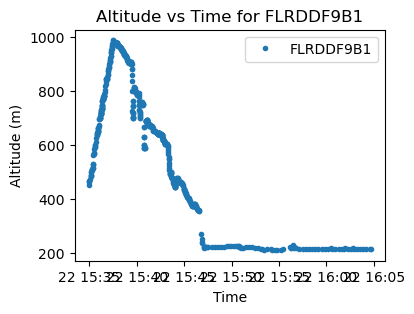

Text(0.5, 1.0, 'Flight path for FLRDDF9B1')

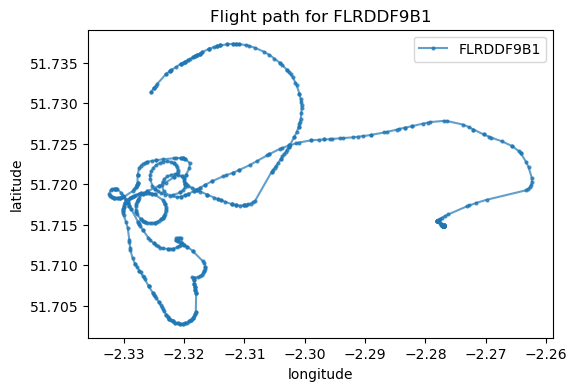

In [ ]:
# Examine the flight path by looking at altitude vs time, and longitude vs latitude. 
# A sawtooth pattern in altitude is a strong indicator of thermal soaring, as the glider climbs in a thermal and then glides down to the next thermal, and so on.

fig = plt.figure(figsize=(4, 3))
# plt.plot(g1df.timestamp[g1df.receiver_name==recvname], g1df.altitude[g1df.receiver_name==recvname], marker='o', linestyle='', markersize=3, label = recvname)
plt.plot(g1df.timestamp, g1df.altitude, marker='o', linestyle='', markersize=3, label = gkey)

plt.legend()
plt.xlabel('Time')  
plt.ylabel('Altitude (m)')
plt.title(f"Altitude vs Time for {gkey}")
plt.show()

fig = plt.figure(figsize=(6, 4))
plt.plot(g1df.longitude[40:-1], g1df.latitude[40:-1], marker='o', linestyle='-', markersize=2, label = gkey, alpha=0.7)
plt.legend()
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.title(f"Flight path for {gkey}")

In [ ]:
# Save out the flight track for this glider to a Parquet file for later analysis.

filename = f"flarm_aprs_{gkey}.parquet"

g1df.to_parquet(filename, index=False)